# 01 — Criação, análise e splits dos datasets MCQ

**Extensão para journal** do paper *"Leveraging LLM Reflection to Improve Small Language Model Agents' Capabilities"* (AGENTICS 2025). **Substitui** o antigo `01_analise_inicial_datasets.ipynb`.

**Mudanças em relação à versão anterior** (motivadas pela análise anterior):

- **AGIEval LSAT → LogiQA 2.0**: o AGIEval tinha 3 questões de "dev" + 230 de teste (sem pool de treino) e vazamento por questões do mesmo "jogo" lógico. O LogiQA 2.0 cobre o mesmo tipo de raciocínio dedutivo com split oficial 12.567/1.569/1.572, labels públicos, tradução revisada por falantes nativos (Liu et al., 2023) e anotações de tipo de raciocínio por questão.
- **MMLU → OpenBookQA**: o MMLU tinha 70 questões de validação vs. 12.032 de teste (pool de treino minúsculo) e coesão interna baixa (multidisciplinar). O OpenBookQA é coeso (ciências), com split oficial 4.957/500/500.

**Matriz experimental final — 3 datasets de *processo* × 3 de *conhecimento*:**

| Dataset | Tipo de erro esperado | Raciocínio dominante | Origem do split |
|---|---|---|---|
| GSM8K (MCQ) | processo | procedural multi-passo | oficial |
| AQuA-RAT | processo | procedural/algébrico | oficial |
| LogiQA 2.0 | processo | dedutivo (lógica formal) | oficial |
| ARC Challenge | conhecimento | indutivo + conhecimento | oficial |
| OpenBookQA | conhecimento | científico (fatos + composição) | oficial |
| Oil & Gas (v2) | conhecimento | técnico de domínio | interno (por grupo, estratificado por `subject`) |

**Política de splits (decisão desta versão):**

- **1.000 questões de treino e 250 de teste** por dataset, **sem validação** — splits oficiais de validação são incorporados ao pool de treino antes da amostragem.
- Seed fixa **42** em toda amostragem; manifest com hash dos IDs para reprodutibilidade.
- **Anti-vazamento**: nenhuma questão de teste pode compartilhar prefixo de contexto (200 chars) nem texto exato com o treino.

**Saídas:** `data/splits/{dataset}_{train,test}.parquet` + `manifest.json`; artefatos de análise em `results/01_*.csv`.


In [1]:
import hashlib, json, re, warnings
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED, TRAIN_N, TEST_N = 42, 1000, 250

DATA    = Path("..") / "data" / "mcq"
SPLITS  = Path("..") / "data" / "splits"
RESULTS = Path("..") / "results"
for p in (SPLITS, RESULTS):
    p.mkdir(parents=True, exist_ok=True)
assert DATA.exists(), f"Dados não encontrados em {DATA.resolve()}"


## 1. Aquisição — LogiQA 2.0 e OpenBookQA

Download idempotente (pula se o parquet já existe em `data/mcq/`) e conversão para o schema canônico do projeto: `id, question, choices{label,text}, answerKey`.

- **OpenBookQA** (`allenai/openbookqa`, config `main`): `question_stem` → `question`; `choices` já vem no formato canônico.
- **LogiQA 2.0** (`jeggers/logiqa2_formatted`, parquet nativo do MRC de csitfun/LogiQA2.0): `question = text (contexto) + "\n\n" + question`; `options` → `choices` com labels A–D; `answer` (0–3) → `answerKey`. As flags de tipo de raciocínio (categórico, disjuntivo, condicional…) são concatenadas em `subject` — permitem análise de erro por tipo e estratificação do split.


In [2]:
def _hf_load(repo, config=None):
    """Carrega dataset do HF Hub; tenta load_dataset e cai para os parquets
    da conversão automática (refs/convert/parquet) se o repo for script-based."""
    try:
        from datasets import load_dataset
        d = load_dataset(repo, config) if config else load_dataset(repo)
        return {s: d[s].to_pandas() for s in d}
    except Exception as e:
        print(f"load_dataset falhou ({type(e).__name__}); tentando parquet do Hub…")
        from huggingface_hub import HfFileSystem
        fs = HfFileSystem()
        base = f"datasets/{repo}@refs%2Fconvert%2Fparquet"
        out = {}
        for split_dir in fs.ls(f"{base}/{config or 'default'}", detail=False):
            split = Path(split_dir).name
            files = [f for f in fs.ls(split_dir, detail=False) if f.endswith(".parquet")]
            out[split] = pd.concat([pd.read_parquet(fs.open(f)) for f in files],
                                   ignore_index=True)
        return out


def fetch_openbookqa():
    if (DATA / "openbookqa" / "train.parquet").exists():
        return "já em disco"
    d = _hf_load("allenai/openbookqa", "main")
    (DATA / "openbookqa").mkdir(exist_ok=True)
    for split in ("train", "validation", "test"):
        raw = d[split]
        df = pd.DataFrame({
            "id":        [f"obqa_{split}_{i:05d}" for i in range(len(raw))],
            "question":  raw["question_stem"],
            "choices":   [{"label": list(c["label"]), "text": list(c["text"])}
                          for c in raw["choices"]],
            "answerKey": raw["answerKey"],
        })
        df.to_parquet(DATA / "openbookqa" / f"{split}.parquet", index=False)
    return "baixado"


TYPE_COLS = ["Categorical Reasoning", "Disjunctive Reasoning", "Conjunctive Reasoning",
             "Necessry Condtional Reasoning", "Sufficient Conditional Reasoning"]


def fetch_logiqa2():
    if (DATA / "logiqa2" / "train.parquet").exists():
        return "já em disco"
    d = _hf_load("jeggers/logiqa2_formatted")
    (DATA / "logiqa2").mkdir(exist_ok=True)
    LBL = list("ABCD")
    for split in ("train", "validation", "test"):
        raw = d[split]
        ctx = raw["text"].astype(str).str.strip()
        types = raw[TYPE_COLS].fillna(False).apply(
            lambda r: "+".join(t.split()[0].lower() for t, v in r.items() if v) or "unspecified",
            axis=1)
        df = pd.DataFrame({
            "id":        [f"logiqa2_{split}_{i:05d}" for i in range(len(raw))],
            "question":  ctx + "\n\n" + raw["question"].astype(str).str.strip(),
            "context":   ctx,
            "choices":   [{"label": LBL, "text": [str(o) for o in ops]}
                          for ops in raw["options"]],
            "answerKey": [LBL[int(i)] for i in raw["answer"]],
            "subject":   types.values,
        })
        df.to_parquet(DATA / "logiqa2" / f"{split}.parquet", index=False)
    return "baixado"


print("openbookqa:", fetch_openbookqa())
print("logiqa2:   ", fetch_logiqa2())


openbookqa: já em disco


Generating train split:   0%|          | 0/12567 [00:00<?, ? examples/s]

Generating train split: 100%|██████████| 12567/12567 [00:00<00:00, 287149.95 examples/s]

Generating test split:   0%|          | 0/1572 [00:00<?, ? examples/s]

Generating test split: 100%|██████████| 1572/1572 [00:00<00:00, 162152.52 examples/s]

Generating validation split:   0%|          | 0/1569 [00:00<?, ? examples/s]

Generating validation split: 100%|██████████| 1569/1569 [00:00<00:00, 178203.12 examples/s]

logiqa2:    baixado


## 2. Carregamento e unificação

Os 6 datasets são unificados no schema canônico. Splits oficiais de **validação entram no pool de treino** (política sem validação). `oil_and_gas` usa a v2 auditada (com `subject`).


In [3]:
FILES = {
    "gsm8k":       ["gsm8k/train.parquet", "gsm8k/test.parquet"],
    "aqua":        ["aqua/train.parquet", "aqua/validation.parquet", "aqua/test.parquet"],
    "logiqa2":     ["logiqa2/train.parquet", "logiqa2/validation.parquet", "logiqa2/test.parquet"],
    "arc":         ["arc/arc_train.parquet", "arc/arc_validation.parquet", "arc/arc_test.parquet"],
    "openbookqa":  ["openbookqa/train.parquet", "openbookqa/validation.parquet", "openbookqa/test.parquet"],
    "oil_and_gas": ["oil_and_gas_v2/test.parquet"],
}


def infer_split(fname):
    n = Path(fname).stem.lower()
    if "train" in n: return "train"
    if "valid" in n or "dev" in n: return "validation"
    return "test"


def norm_choices(c):
    return {"label": [str(x) for x in c["label"]], "text": [str(x) for x in c["text"]]}


frames = []
for ds, paths in FILES.items():
    for p in paths:
        df = pd.read_parquet(DATA / p)
        keep = pd.DataFrame({
            "dataset":   ds,
            "split":     infer_split(p),
            "id":        df["id"].astype(str),
            "question":  df["question"].astype(str),
            "choices":   df["choices"].apply(norm_choices),
            "answerKey": df["answerKey"].astype(str),
            "subject":   df["subject"].astype(str) if "subject" in df else None,
        })
        frames.append(keep)

all_df = pd.concat(frames, ignore_index=True)
all_df["n_choices"] = all_df["choices"].apply(lambda c: len(c["text"]))
print(f"{len(all_df):,} questões em {all_df.dataset.nunique()} datasets")


133,568 questões em 6 datasets


In [4]:
overview = (all_df.pivot_table(index="dataset", columns="split", values="id",
                               aggfunc="count", fill_value=0)
            .reindex(columns=["train", "validation", "test"], fill_value=0))
overview["total"] = overview.sum(axis=1)
overview["pool_treino (train+val)"] = overview["train"] + overview["validation"]
overview["n_choices (moda)"] = all_df.groupby("dataset")["n_choices"].agg(lambda s: s.mode()[0])
overview


split,train,validation,test,total,pool_treino (train+val),n_choices (moda)
dataset,,,,,,
aqua,97467,254,254,97975,97721,5
arc,1119,299,1172,2590,1418,4
gsm8k,7473,0,1319,8792,7473,4
logiqa2,12567,1569,1572,15708,14136,4
oil_and_gas,0,0,2546,2546,0,4
openbookqa,4957,500,500,5957,5457,4


**Leitura:** ao contrário da versão anterior (AGIEval com 3 questões de treino; MMLU com 70), todos os datasets agora têm pool de treino ≥ TRAIN_N, exceto `oil_and_gas`, que será particionado internamente (§6). Nenhum hack de split é necessário nos demais.

### Distribuição do gabarito por posição

Viés posicional importa para o baseline de retry: o feedback "incorreto" elimina uma alternativa.


In [5]:
gab = all_df.groupby(["dataset", "answerKey"]).size().unstack(fill_value=0)
gab.div(gab.sum(axis=1), axis=0).round(3)


answerKey,1,2,3,4,A,B,C,D,E
dataset,,,,,,,,,
aqua,0.000,0.000,0.000,0.000,0.211,0.220,0.228,0.199,0.141
arc,0.004,0.005,0.004,0.005,0.215,0.257,0.258,0.250,0.000
gsm8k,0.000,0.000,0.000,0.000,0.255,0.248,0.256,0.241,0.000
logiqa2,0.000,0.000,0.000,0.000,0.225,0.245,0.263,0.267,0.000
oil_and_gas,0.000,0.000,0.000,0.000,0.124,0.431,0.421,0.024,0.000
openbookqa,0.000,0.000,0.000,0.000,0.276,0.248,0.233,0.244,0.000


## 3. Estatísticas textuais

Vocabulário e TTR dependem do tamanho do corpus → versões normalizadas em amostras de 200 questões. A **densidade numérica** é proxy de raciocínio procedural/matemático.


In [6]:
TOKEN_RE = re.compile(r"[A-Za-z]+|\d+(?:[.,]\d+)?")
NUM_RE = re.compile(r"^\d")


def tokens(text):
    return [t.lower() for t in TOKEN_RE.findall(str(text))]


all_df["q_tokens"] = all_df["question"].apply(tokens)
all_df["q_len"] = all_df["q_tokens"].apply(len)
all_df["num_density"] = all_df["q_tokens"].apply(
    lambda ts: sum(bool(NUM_RE.match(t)) for t in ts) / max(len(ts), 1))

rows = {}
for ds, g in all_df.groupby("dataset"):
    samp = g.sample(min(200, len(g)), random_state=SEED)
    toks = [t for ts in samp["q_tokens"] for t in ts]
    rows[ds] = {
        "palavras/questão (média)": g["q_len"].mean().round(1),
        "densidade numérica": g["num_density"].mean().round(3),
        "vocab (amostra 200q)": len(set(toks)),
        "TTR (amostra 200q)": round(len(set(toks)) / len(toks), 3),
    }
text_stats = pd.DataFrame(rows).T
text_stats


,palavras/questão (média),densidade numérica,vocab (amostra 200q),TTR (amostra 200q)
aqua,33.2,0.127,1313.0,0.197
arc,22.5,0.006,1321.0,0.296
gsm8k,45.9,0.078,1729.0,0.188
logiqa2,84.2,0.008,3332.0,0.203
oil_and_gas,10.4,0.004,664.0,0.318
openbookqa,10.7,0.001,796.0,0.362


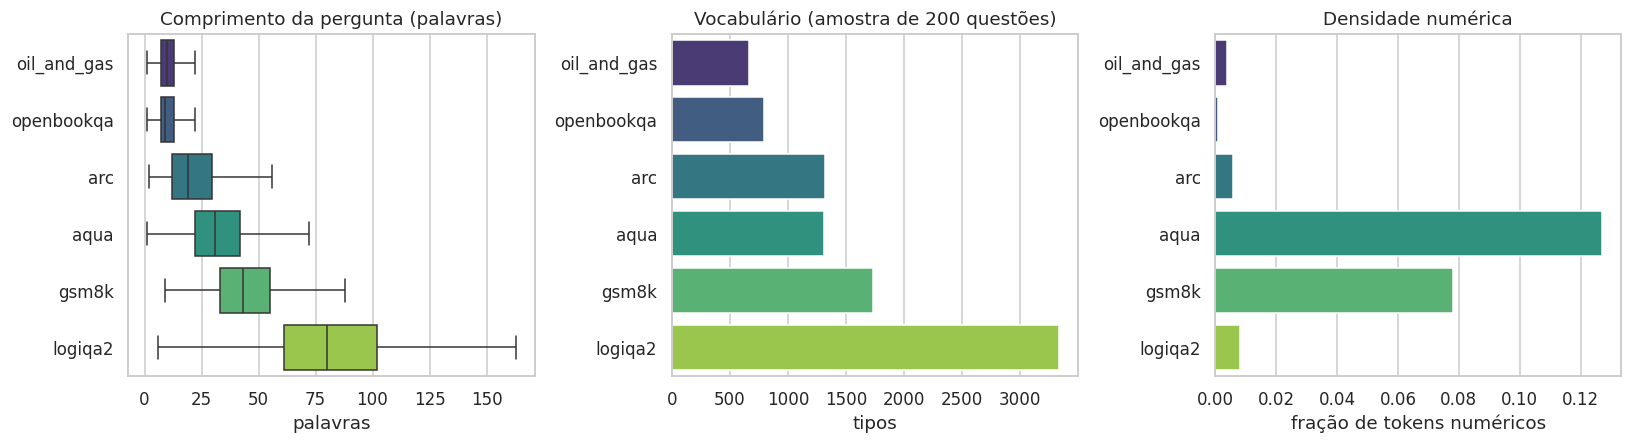

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
order = text_stats.sort_values("palavras/questão (média)").index

sns.boxplot(data=all_df, x="q_len", y="dataset", order=order, ax=axes[0],
            showfliers=False, palette="viridis")
axes[0].set(title="Comprimento da pergunta (palavras)", xlabel="palavras", ylabel="")

sns.barplot(x=text_stats.loc[order, "vocab (amostra 200q)"], y=order,
            ax=axes[1], palette="viridis")
axes[1].set(title="Vocabulário (amostra de 200 questões)", xlabel="tipos", ylabel="")

sns.barplot(x=text_stats.loc[order, "densidade numérica"], y=order,
            ax=axes[2], palette="viridis")
axes[2].set(title="Densidade numérica", xlabel="fração de tokens numéricos", ylabel="")
plt.tight_layout(); plt.show()


## 4. Proximidade léxica e semântica entre datasets

Jaccard de vocabulário e similaridade de cosseno (TF-IDF → SVD-50), em amostras de até 300 questões/dataset. A **diagonal** da matriz de cosseno mede a coesão interna — datasets coesos favorecem a recuperação de reflexões relevantes na Fase 3. Também fundamenta a decisão D5 (memória por dataset vs. compartilhada).


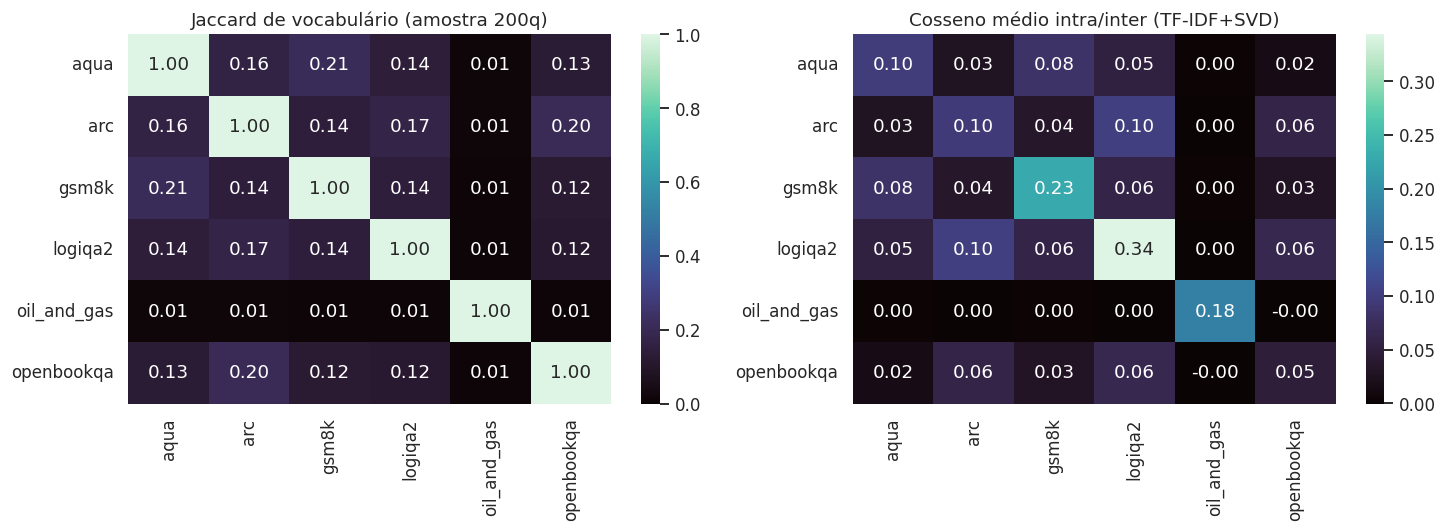

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

names = sorted(all_df.dataset.unique())

vocabs = {}
for ds, g in all_df.groupby("dataset"):
    samp = g.sample(min(200, len(g)), random_state=SEED)
    vocabs[ds] = set().union(*samp["q_tokens"])

J = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        J.loc[a, b] = len(vocabs[a] & vocabs[b]) / len(vocabs[a] | vocabs[b])

sample = (all_df.groupby("dataset", group_keys=False)
          .apply(lambda g: g.sample(min(300, len(g)), random_state=SEED))
          .reset_index(drop=True))
tfidf = TfidfVectorizer(max_features=20000, sublinear_tf=True, stop_words="english")
Xr = TruncatedSVD(50, random_state=SEED).fit_transform(tfidf.fit_transform(sample["question"]))

sim = cosine_similarity(Xr)
labels = sample["dataset"].values
S = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    ia = np.where(labels == a)[0]
    for b in names:
        ib = np.where(labels == b)[0]
        block = sim[np.ix_(ia, ib)]
        if a == b:
            block = block[~np.eye(len(ia), dtype=bool)]
        S.loc[a, b] = block.mean()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
sns.heatmap(J.astype(float), annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Jaccard de vocabulário (amostra 200q)")
sns.heatmap(S.astype(float), annot=True, fmt=".2f", cmap="mako", ax=axes[1])
axes[1].set_title("Cosseno médio intra/inter (TF-IDF+SVD)")
plt.tight_layout(); plt.show()


**Leitura esperada:** blocos matemáticos (gsm8k/aqua) próximos entre si; logiqa e openbookqa devem apresentar coesão interna maior que os substituídos (AGIEval sem pool; MMLU disperso). Inter-dataset baixo → mantém a decisão de **memória de reflexões por dataset**.

## 5. Vazamento por contexto compartilhado

A fragilidade nº 3 do paper original era medir memorização. Aqui verificamos, **antes de congelar os splits**, se questões compartilham enunciado-base (prefixo de 200 chars como proxy de grupo). Foi exatamente esse check que desqualificou o split aleatório do AGIEval na análise anterior.


In [9]:
def prefix(s):
    return str(s)[:200]


leak_rows = {}
for ds in names:
    g = all_df[all_df.dataset == ds]
    pref = g["question"].map(prefix)
    vc = pref.value_counts()
    tr_pool = g[g.split.isin(["train", "validation"])]
    te_pool = g[g.split == "test"]
    shared = (set(tr_pool["question"].map(prefix)) & set(te_pool["question"].map(prefix))
              if len(tr_pool) else set())
    leak_rows[ds] = {
        "questões": len(g),
        "contextos únicos": pref.nunique(),
        "máx. questões/contexto": int(vc.iloc[0]),
        "prefixos compartilhados treino×teste (oficial)": len(shared),
    }
leak = pd.DataFrame(leak_rows).T
leak


,questões,contextos únicos,máx. questões/contexto,prefixos compartilhados treino×teste (oficial)
aqua,97975,78645,52,12
arc,2590,2576,3,9
gsm8k,8792,8792,1,0
logiqa2,15708,14090,12,256
oil_and_gas,2546,2540,2,0
openbookqa,5957,5798,7,22


**Regra derivada:** qualquer prefixo compartilhado entre treino e teste é eliminado do teste na construção dos splits (§6). Para `oil_and_gas` (split interno), o particionamento é feito **por grupo de contexto**, nunca por questão.

## 6. Construção dos splits finais

Regras (todas com seed 42):

1. **Pool de treino** = train + validation oficiais; **pool de teste** = test oficial.
2. `oil_and_gas` (sem split oficial): grupos de contexto embaralhados; grupos são atribuídos ao teste até formar um pool de candidatos ≥ 4×TEST_N; o restante forma o pool de treino. Amostragem estratificada por `subject`.
3. Treino: amostra de **1.000** (estratificada por `subject` quando existir; uniforme caso contrário).
4. Teste: candidatos = pool de teste **menos** questões que compartilham prefixo de contexto ou texto exato com o treino amostrado; amostra de **250**.
5. Se um pool for menor que o alvo, usa-se o pool inteiro (reportado no manifest).


In [10]:
def stratified_sample(df, n, col="subject"):
    n = min(n, len(df))
    if col not in df or df[col].isna().all() or df[col].nunique() <= 1:
        return df.sample(n, random_state=SEED)
    parts = []
    for _, g in df.groupby(col):
        k = int(round(n * len(g) / len(df)))
        parts.append(g.sample(min(max(k, 1), len(g)), random_state=SEED))
    out = pd.concat(parts)
    if len(out) > n:
        out = out.sample(n, random_state=SEED)
    elif len(out) < n:
        rest = df.drop(out.index)
        out = pd.concat([out, rest.sample(n - len(out), random_state=SEED)])
    return out


def get_pools(ds):
    g = all_df[all_df.dataset == ds]
    tr_pool = g[g.split.isin(["train", "validation"])]
    te_pool = g[g.split == "test"]
    if len(tr_pool) == 0:  # split interno por grupo de contexto
        te_pool = te_pool.copy()
        grp = te_pool["question"].map(prefix)
        groups = grp.drop_duplicates().sample(frac=1, random_state=SEED).tolist()
        test_groups, count = set(), 0
        for gname in groups:
            if count >= 4 * TEST_N:
                break
            test_groups.add(gname)
            count += (grp == gname).sum()
        mask = grp.isin(test_groups)
        tr_pool, te_pool = te_pool[~mask], te_pool[mask]
    return tr_pool, te_pool


splits, split_report = {}, {}
for ds in names:
    tr_pool, te_pool = get_pools(ds)
    tr = stratified_sample(tr_pool, TRAIN_N)
    banned = set(tr["question"].map(prefix)) | set(tr["question"])
    te_cand = te_pool[~te_pool["question"].map(prefix).isin(banned)
                      & ~te_pool["question"].isin(banned)]
    te = stratified_sample(te_cand, TEST_N)
    splits[ds] = (tr, te)
    split_report[ds] = {
        "pool_treino": len(tr_pool), "pool_teste": len(te_pool),
        "treino": len(tr), "teste": len(te),
        "removidos por vazamento": len(te_pool) - len(te_cand),
    }

report = pd.DataFrame(split_report).T
report


,pool_treino,pool_teste,treino,teste,removidos por vazamento
aqua,97721,254,1000,250,0
arc,1418,1172,1000,250,7
gsm8k,7473,1319,1000,250,0
logiqa2,14136,1572,1000,250,25
oil_and_gas,1546,1000,1000,250,0
openbookqa,5457,500,1000,250,2


In [11]:
# Sanidade: alvos atingidos e disjunção total treino×teste
for ds, (tr, te) in splits.items():
    assert len(tr) == min(TRAIN_N, report.loc[ds, "pool_treino"]), ds
    assert len(te) == min(TEST_N, report.loc[ds, "pool_teste"]), ds
    assert not set(tr["id"]) & set(te["id"]), f"{ds}: overlap de id"
    assert not set(tr["question"]) & set(te["question"]), f"{ds}: overlap de texto"
    assert not set(tr["question"].map(prefix)) & set(te["question"].map(prefix)), \
        f"{ds}: overlap de contexto"
print("OK — splits disjuntos (id, texto e contexto) em todos os datasets")


OK — splits disjuntos (id, texto e contexto) em todos os datasets


## 7. Viabilidade da recuperação treino→teste (splits finais)

A Fase 3 recupera reflexões por similaridade (top-k). Medimos, **nos splits reais que serão usados**, a similaridade da questão de teste com sua vizinha mais próxima no treino (TF-IDF, proxy léxico — a Fase 3 usará sentence embeddings). Similaridade máxima baixa ⇒ *Transferability* prevista baixa, independentemente da qualidade da reflexão. Valores ≈1.0 indicariam vazamento — agora estruturalmente impossíveis pela §6.


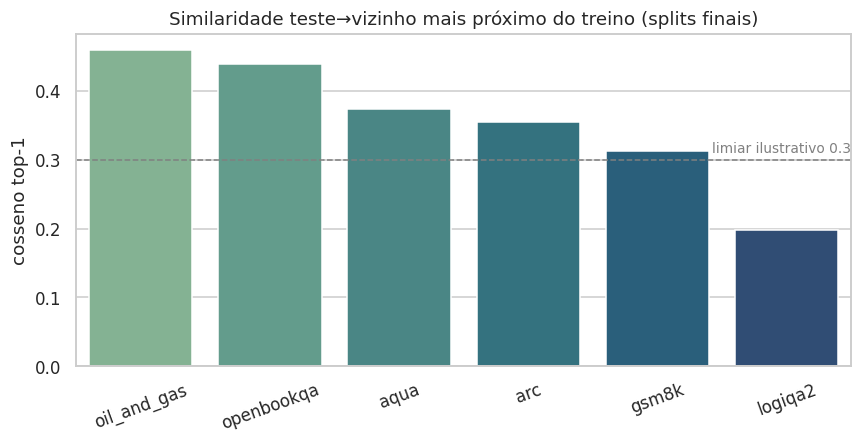

,sim_top1 (média),sim_top1 (p90),% teste com sim_top1 ≥ 0.3,pool_treino
aqua,0.373,0.551,69.2,1000.0
arc,0.354,0.528,61.2,1000.0
gsm8k,0.312,0.441,48.8,1000.0
logiqa2,0.198,0.279,7.6,1000.0
oil_and_gas,0.459,0.644,94.0,1000.0
openbookqa,0.439,0.662,86.8,1000.0


In [12]:
retr_rows = {}
for ds, (tr, te) in splits.items():
    tfidf = TfidfVectorizer(max_features=20000, sublinear_tf=True, stop_words="english")
    Xtr = tfidf.fit_transform(tr["question"])
    Xte = tfidf.transform(te["question"])
    sims = cosine_similarity(Xte, Xtr)
    top1 = sims.max(axis=1)
    retr_rows[ds] = {
        "sim_top1 (média)": round(top1.mean(), 3),
        "sim_top1 (p90)": round(np.quantile(top1, 0.9), 3),
        "% teste com sim_top1 ≥ 0.3": round((top1 >= 0.3).mean() * 100, 1),
        "pool_treino": len(tr),
    }
retrieval = pd.DataFrame(retr_rows).T

fig, ax = plt.subplots(figsize=(8, 4.2))
r = retrieval.sort_values("sim_top1 (média)", ascending=False)
sns.barplot(x=r.index, y=r["sim_top1 (média)"], palette="crest", ax=ax)
ax.axhline(0.3, ls="--", c="gray", lw=1)
ax.text(len(r) - 0.5, 0.31, "limiar ilustrativo 0.3", ha="right", c="gray", fontsize=9)
ax.set(title="Similaridade teste→vizinho mais próximo do treino (splits finais)",
       ylabel="cosseno top-1", xlabel="")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()
retrieval


## 8. Expectativa de impacto da reflexão por dataset

**Hipótese central da extensão:** reflexão externa ajuda onde o erro é de **processo** (correção procedimental transferível) e ajuda pouco onde o erro é de **conhecimento faltante**. Cruzamos os proxies medidos com o tipo de raciocínio dominante:


In [13]:
reasoning = {
    "gsm8k":       ("procedural multi-passo",        "processo"),
    "aqua":        ("procedural/algébrico",          "processo"),
    "logiqa2":     ("dedutivo (lógica formal)",      "processo"),
    "arc":         ("indutivo + conhecimento",       "conhecimento"),
    "openbookqa":  ("científico (fatos+composição)", "conhecimento"),
    "oil_and_gas": ("técnico de domínio",            "conhecimento"),
}

impact = pd.DataFrame({
    "raciocínio dominante": pd.Series({k: v[0] for k, v in reasoning.items()}),
    "tipo de erro esperado": pd.Series({k: v[1] for k, v in reasoning.items()}),
    "densidade numérica": text_stats["densidade numérica"],
    "coesão interna": pd.Series(np.diag(S.values.astype(float)).round(3), index=S.index),
    "sim treino→teste (top1)": retrieval["sim_top1 (média)"],
})


def expectativa(row):
    score = 2 * (row["tipo de erro esperado"] == "processo")
    score += row["sim treino→teste (top1)"] >= impact["sim treino→teste (top1)"].median()
    score += row["coesão interna"] >= impact["coesão interna"].median()
    return {0: "baixa", 1: "baixa", 2: "média", 3: "alta", 4: "alta"}[int(score)]


impact["impacto esperado da reflexão"] = impact.apply(expectativa, axis=1)
impact.sort_values("impacto esperado da reflexão")


,raciocínio dominante,tipo de erro esperado,densidade numérica,coesão interna,sim treino→teste (top1),impacto esperado da reflexão
aqua,procedural/algébrico,processo,0.127,0.099,0.373,alta
gsm8k,procedural multi-passo,processo,0.078,0.228,0.312,alta
logiqa2,dedutivo (lógica formal),processo,0.008,0.344,0.198,alta
arc,indutivo + conhecimento,conhecimento,0.006,0.096,0.354,baixa
openbookqa,científico (fatos+composição),conhecimento,0.001,0.048,0.439,baixa
oil_and_gas,técnico de domínio,conhecimento,0.004,0.179,0.459,média


**Discussão por dataset (rótulos da tabela acima):**

- **GSM8K / AQuA (alta).** Erros de processo (aritmética multi-passo, montagem de equação); reflexões *instructions/explanation* devem transferir entre questões estruturalmente similares. Mantém-se o cuidado da D6: auditar distratores da conversão MCQ do GSM8K antes de rodar.
- **LogiQA 2.0 (alta pelo tipo de erro, com ressalva).** Substitui o AGIEval com a mesma aposta (erro de processo dedutivo), pool de treino real e sem vazamento por "jogo"; a v2.0 corrige a tradução da v1 e traz anotações de tipo de raciocínio (em `subject`), que estratificam o split e permitem *Error Persistence* por tipo. Ressalva: a sim treino→teste tende a ser a mais baixa da matriz (contextos narrativos muito variados) — se a reflexão ajudar aqui, o efeito é *procedimental abstrato*, não recuperação de vizinhos próximos. É o teste mais informativo da hipótese.
- **ARC (baixa).** Âncora de comparabilidade com o paper original; a previsão segue: o ganho do protocolo mesma-questão deve encolher no protocolo treino→teste.
- **OpenBookQA (baixa, apesar de recuperável).** Conhecimento científico coeso com sim treino→teste alta: se a reflexão ajudar aqui mais que no ARC, sugere que recuperabilidade modula o efeito mesmo em erro de conhecimento — refinamento interessante da hipótese.
- **Oil & Gas (média pela recuperabilidade).** Erro de conhecimento, mas coesão e sim treino→teste altas (questões técnicas repetitivas) puxam o rótulo para cima. Por ser proprietário, é o caso de maior valor aplicado.

## 9. Salvamento dos splits e artefatos


In [14]:
SAVE_COLS = ["id", "dataset", "question", "choices", "answerKey", "subject"]


def sha_ids(df):
    return hashlib.sha256("".join(sorted(df["id"])).encode()).hexdigest()[:12]


manifest = {"_meta": {
    "created": date.today().isoformat(), "seed": SEED,
    "train_n": TRAIN_N, "test_n": TEST_N, "validation": None,
    "policy": "train=official(train+val) sample; test=official test sample, "
              "anti-leak por prefixo(200) e texto exato; oil_and_gas: split interno "
              "por grupo de contexto, estratificado por subject",
    "notebook": "01_datasets_criacao_analise_splits.ipynb",
}}

# Remove splits órfãos de versões anteriores (datasets substituídos); os demais
# são sobrescritos. Tolerante a sistemas com proteção de exclusão.
expected = {f"{ds}_{s}.parquet" for ds in splits for s in ("train", "test")}
for old in SPLITS.glob("*.parquet"):
    if old.name not in expected:
        try:
            old.unlink()
        except OSError as e:
            print(f"aviso: não foi possível remover {old.name} ({e}); ignore ou remova manualmente")

for ds, (tr, te) in splits.items():
    for split_name, df in (("train", tr), ("test", te)):
        out = df[SAVE_COLS].reset_index(drop=True)
        out.to_parquet(SPLITS / f"{ds}_{split_name}.parquet", index=False)
        manifest[f"{ds}_{split_name}"] = {
            "n": len(out), "seed": SEED, "sha": sha_ids(out),
            "removidos_por_vazamento": (int(report.loc[ds, "removidos por vazamento"])
                                        if split_name == "test" else 0),
        }

(SPLITS / "manifest.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))

text_stats.to_csv(RESULTS / "01_text_stats.csv")
overview.to_csv(RESULTS / "01_split_overview.csv")
leak.to_csv(RESULTS / "01_leakage_check.csv")
report.to_csv(RESULTS / "01_split_report.csv")
retrieval.to_csv(RESULTS / "01_retrieval_feasibility.csv")
impact.to_csv(RESULTS / "01_reflection_impact_expectation.csv")
J.to_csv(RESULTS / "01_vocab_jaccard.csv")
S.to_csv(RESULTS / "01_semantic_similarity.csv")

print("Splits salvos em", SPLITS.resolve())
for f in sorted(SPLITS.glob("*")):
    print(" -", f.name)


Splits salvos em /sessions/dazzling-fervent-shannon/mnt/eagle/journal_extension/data/splits
 - aqua_test.parquet
 - aqua_train.parquet
 - arc_test.parquet
 - arc_train.parquet
 - gsm8k_test.parquet
 - gsm8k_train.parquet
 - logiqa2_test.parquet
 - logiqa2_train.parquet
 - manifest.json
 - oil_and_gas_test.parquet
 - oil_and_gas_train.parquet
 - openbookqa_test.parquet
 - openbookqa_train.parquet


## 10. Verificação final

Releitura do que foi salvo em disco (não das variáveis em memória): contagens, disjunção e consistência com o manifest.


In [15]:
man = json.loads((SPLITS / "manifest.json").read_text())
ok = True
for ds in names:
    tr = pd.read_parquet(SPLITS / f"{ds}_train.parquet")
    te = pd.read_parquet(SPLITS / f"{ds}_test.parquet")
    checks = [
        len(tr) == man[f"{ds}_train"]["n"],
        len(te) == man[f"{ds}_test"]["n"],
        hashlib.sha256("".join(sorted(tr["id"])).encode()).hexdigest()[:12] == man[f"{ds}_train"]["sha"],
        hashlib.sha256("".join(sorted(te["id"])).encode()).hexdigest()[:12] == man[f"{ds}_test"]["sha"],
        not set(tr["id"]) & set(te["id"]),
        not set(tr["question"].str[:200]) & set(te["question"].str[:200]),
        tr["answerKey"].notna().all() and te["answerKey"].notna().all(),
    ]
    ok &= all(checks)
    print(f"{ds:12s} treino={len(tr):4d} teste={len(te):3d} "
          f"{'✓' if all(checks) else '✗ FALHOU: ' + str(checks)}")
assert ok, "verificação final falhou"
print("\nVerificação final: OK — splits prontos para o notebook 02 (Fase 1).")


aqua         treino=1000 teste=250 ✓
arc          treino=1000 teste=250 ✓
gsm8k        treino=1000 teste=250 ✓
logiqa2      treino=1000 teste=250 ✓
oil_and_gas  treino=1000 teste=250 ✓
openbookqa   treino=1000 teste=250 ✓

Verificação final: OK — splits prontos para o notebook 02 (Fase 1).
